In [59]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [61]:
df = pd.read_csv("/content/brest_cancer.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)



First 5 rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_wor

In [62]:
 #Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Remove unnecessary ID column if present
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Remove unnamed columns if present
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]


Missing values:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_wors

In [63]:
# Common Breast Cancer dataset:
# diagnosis = M (Malignant), B (Benign)

if 'diagnosis' in df.columns:
    df['diagnosis'] = df['diagnosis'].map({
        'M': 1,
        'B': 0
    })

In [64]:

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("\nFeatures:")
print(X.columns)

print("\nTarget:")
print(y.value_counts())



Features:
Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

Target:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (455, 30)
Testing data: (114, 30)


In [66]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [67]:
k_values = range(1, 21)

accuracies = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)

    accuracies.append(accuracy)

In [68]:
for k, acc in zip(k_values, accuracies):
    print(f"K = {k}, Accuracy = {acc:.4f}")

# Best K
best_k = k_values[np.argmax(accuracies)]

print("\nBest K:", best_k)
print("Best Accuracy:", max(accuracies))

K = 1, Accuracy = 0.9298
K = 2, Accuracy = 0.9123
K = 3, Accuracy = 0.9386
K = 4, Accuracy = 0.9386
K = 5, Accuracy = 0.9561
K = 6, Accuracy = 0.9474
K = 7, Accuracy = 0.9561
K = 8, Accuracy = 0.9474
K = 9, Accuracy = 0.9474
K = 10, Accuracy = 0.9474
K = 11, Accuracy = 0.9474
K = 12, Accuracy = 0.9474
K = 13, Accuracy = 0.9474
K = 14, Accuracy = 0.9386
K = 15, Accuracy = 0.9474
K = 16, Accuracy = 0.9386
K = 17, Accuracy = 0.9386
K = 18, Accuracy = 0.9386
K = 19, Accuracy = 0.9386
K = 20, Accuracy = 0.9386

Best K: 5
Best Accuracy: 0.956140350877193


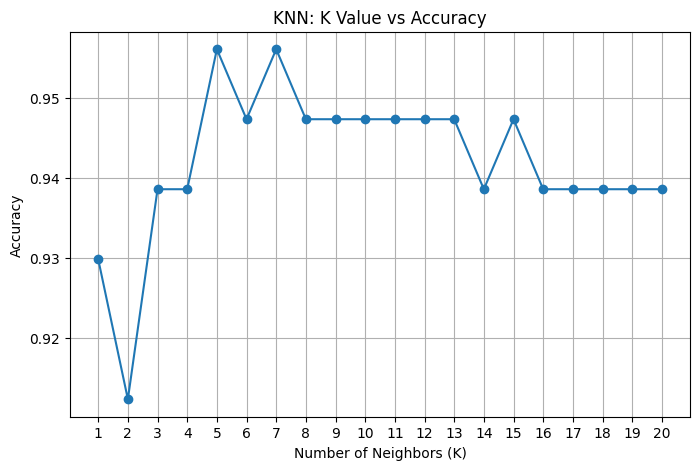

In [69]:

plt.figure(figsize=(8, 5))

plt.plot(k_values, accuracies, marker='o')

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")

plt.title("KNN: K Value vs Accuracy")

plt.xticks(k_values)

plt.grid()

plt.show()

In [70]:
knn_model = KNeighborsClassifier(
    n_neighbors=best_k
)

knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [71]:
y_pred = knn_model.predict(X_test_scaled)

In [72]:
accuracy = accuracy_score(y_test, y_pred)

print("\n================================")
print("FINAL KNN MODEL")
print("================================")

print("Best K:", best_k)

print("Accuracy:", accuracy)

print("Accuracy (%):", accuracy * 100)


FINAL KNN MODEL
Best K: 5
Accuracy: 0.956140350877193
Accuracy (%): 95.6140350877193



Confusion Matrix:
[[71  1]
 [ 4 38]]


<Axes: >

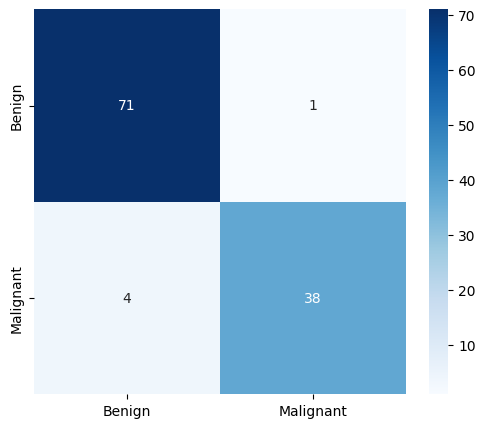

In [73]:

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant']
)

In [75]:
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Benign', 'Malignant']
    )
)


Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



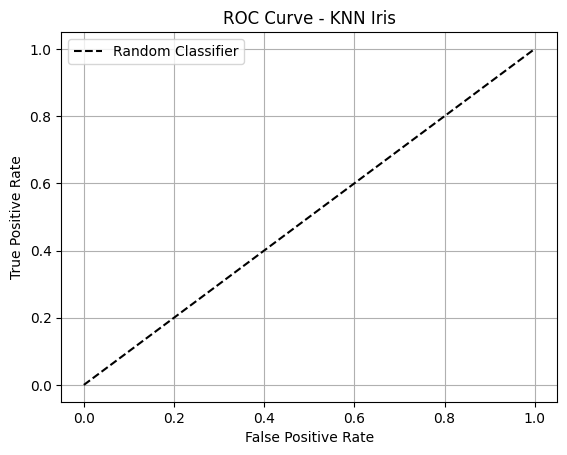

In [76]:
#print roc curve
# Random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN Iris')
plt.legend()
plt.grid()
plt.show()